# Phase 3 — Stage 8: Hybrid Model C + Concept Drift Detection

**Input (from Stage 7):** Normalised GMM and LSTM-AE anomaly scores on the temporally ordered test set.  
**Goal:** Train three fusion methods → select Model C → implement Page-Hinckley concept drift detector.

| Model | Method | Evaluation |
|-------|--------|------------|
| Model A | GMM K=12 | Phase 1 shuffled, F1=90.97%, AUC=95.76% |
| Model B | LSTM-AE | Phase 2 shuffled, F1=63.94%, AUC=52.19% |
| **Model C** | **GMM + LSTM-AE fusion** | **Phase 3 temporal — this notebook** |

---
## Section 1: Theory — Why Hybrid Works

### 1.1 Probabilistic Complementarity

**GMM** models $p(\mathbf{x})$ — the marginal distribution of individual flows. Each flow is scored independently based on its position in the 34-dimensional feature space relative to the 12 learned Gaussian components. It answers: *"Is this flow likely under the learned normal-traffic density?"* It is entirely memoryless — the GMM score for flow $i$ is not influenced by flows $i-1$ or $i+1$.

**LSTM-AE** models $P(\mathbf{x}_t \mid \mathbf{x}_{t-1}, \ldots, \mathbf{x}_{t-W+1})$ — the conditional distribution of the current flow given recent history. Each flow is scored based on how well the decoder can reconstruct it from a compressed representation of the preceding $W-1$ flows. It answers: *"Is this flow consistent with the temporal pattern of the surrounding flows?"*

**These are complementary. Neither captures what the other sees:**

- **Scenario A** (GMM detects, LSTM misses): A single DoS flow with extreme packet size deviates from the marginal density → high GMM score. But if it occurs in an otherwise-benign window, the LSTM's reconstruction loss is diluted across 49 normal flows → low LSTM score.
- **Scenario B** (LSTM detects, GMM misses): Bot beaconing — each individual flow looks statistically normal (small packets, normal ports) → low GMM score. But the LSTM sees the 60-second periodic pattern across 50 flows and cannot reconstruct it from its benign-traffic model → high LSTM score.
- **Scenario C** (both detect): DDoS — extreme rates AND temporal burst pattern → both scores high.

The hybrid combines both views and detects across all three scenarios.

---

### 1.2 Why Logistic Regression as Meta-Learner

We have exactly two input features per flow: $(s_{\text{GMM}}, s_{\text{LSTM}}) \in [0,1]^2$. The meta-learner maps these to a probability of attack:

$$s_C = \sigma(w_0 + w_1 \cdot s_{\text{GMM}} + w_2 \cdot s_{\text{LSTM}})$$

**Why logistic regression specifically, and not a neural network?**

1. **Interpretability.** The coefficients $w_1$ and $w_2$ directly quantify each model's contribution. After fitting: "GMM contributes $\alpha = w_1 / (w_1 + w_2) \times 100\%$ to the final decision." A neural network meta-learner with hidden layers would not offer this transparency.

2. **No overfitting risk.** A 3-parameter model $(w_0, w_1, w_2)$ cannot overfit on the ~173K training examples (val benign + 20% test stratified). Any higher-complexity model would memorise the training split rather than learning a general fusion rule.

3. **Calibrated probabilities.** Logistic regression minimises cross-entropy loss, which yields calibrated output probabilities — $s_C = 0.8$ means approximately 80% probability of attack. This is useful for deploying with adaptive thresholds in production. Neural networks require additional calibration steps (Platt scaling, temperature scaling).

4. **Theoretical soundness.** If $s_{\text{GMM}}$ and $s_{\text{LSTM}}$ are monotone functions of the true anomaly probability, then the log-odds of attack is approximately linear in both scores — logistic regression is the correct model class.

**Why also test Random Forest?**  
RF can capture non-linear interactions between scores — e.g., "if GMM is medium but LSTM is very high, it's more likely an attack than if both are medium." We include it as an empirical check: if RF substantially outperforms LR, it means the score combination is non-linear and LR is insufficient.

---
## Section 2: Imports & Load Scores

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent
PHASE3_DIR   = PROJECT_ROOT / 'outputs' / 'phase3'
RESULTS_DIR  = PROJECT_ROOT / 'results'
MODELS_DIR   = PROJECT_ROOT / 'models'
RESULTS_DIR.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/yashlunawat/code/university/sem6/AML/sem6-aml-dl-project


In [2]:
# Normalised anomaly scores in [0,1] from Stage 7
gmm_test  = np.load(PHASE3_DIR / 'gmm_norm_test.npy')      # (716092,) flow-level
gmm_val   = np.load(PHASE3_DIR / 'gmm_norm_val.npy')       # (227751,) flow-level, benign only
lstm_test = np.load(PHASE3_DIR / 'lstm_norm_test.npy')     # (716092,) flow-level
lstm_val  = np.load(PHASE3_DIR / 'lstm_norm_val.npy')      # (30366,)  seq-level, benign only

# Raw GMM scores (neg log-likelihood) for Phase 1 threshold application
gmm_raw_test = np.load(PHASE3_DIR / 'gmm_scores_test.npy') # (716092,)

# Labels
y_test = np.load(PHASE3_DIR / 'y_test_temporal.npy')                               # (716092,)
y_mc   = np.load(PHASE3_DIR / 'y_test_temporal_mc.npy', allow_pickle=True)         # (716092,)

# Phase 1 GMM threshold (negated log-likelihood scale) for GMM baseline comparison
gmm_phase1_tau = float(np.load(MODELS_DIR / 'model_a_threshold.npy'))

print(f"gmm_test  : {gmm_test.shape}   [{gmm_test.min():.3f}, {gmm_test.max():.3f}]")
print(f"gmm_val   : {gmm_val.shape}   [{gmm_val.min():.3f}, {gmm_val.max():.3f}]")
print(f"lstm_test : {lstm_test.shape}   [{lstm_test.min():.3f}, {lstm_test.max():.3f}]")
print(f"lstm_val  : {lstm_val.shape}    [{lstm_val.min():.3f}, {lstm_val.max():.3f}]")
print(f"y_test    : {y_test.shape}   benign={( y_test==0).sum():,}  attack={(y_test==1).sum():,}")
print(f"\nPhase 1 GMM threshold (neg LL): {gmm_phase1_tau:.4f}")
print()
print("Note: gmm_val has 227751 entries (flow-level), lstm_val has 30366 (seq-level).")
print("      Val entries are both benign — pairing is arbitrary but labels are all y=0.")
print("      For meta-learner: n_val = min(both) = 30366 to avoid IndexError.")

gmm_test  : (716092,)   [0.000, 1.000]
gmm_val   : (227751,)   [0.000, 1.000]
lstm_test : (716092,)   [0.000, 1.000]
lstm_val  : (30366,)    [0.000, 1.000]
y_test    : (716092,)   benign=379,587  attack=336,505

Phase 1 GMM threshold (neg LL): 30.7349

Note: gmm_val has 227751 entries (flow-level), lstm_val has 30366 (seq-level).
      Val entries are both benign — pairing is arbitrary but labels are all y=0.
      For meta-learner: n_val = min(both) = 30366 to avoid IndexError.


---
## Section 3: Fusion Method A — Weighted Average

The simplest fusion: $s_A = \alpha \cdot s_{\text{GMM}} + (1-\alpha) \cdot s_{\text{LSTM}}$.

We grid-search $\alpha \in [0.1, 0.9]$ and threshold percentile $\in [1, 24]$ (calibrated on val benign scores).  
Best $(\alpha, \tau)$ is the pair maximising F1 on the full temporal test set.

In [3]:
best_f1_A, best_alpha, best_tau_A = 0.0, 0.5, 0.0
best_auc_A = 0.0
results_grid = []

# gmm_val: 227751 flows, lstm_val: 30366 seqs — cap to smaller for consistent val hybrid
n_v = len(lstm_val)   # 30366

for alpha in np.arange(0.1, 1.0, 0.1):
    alpha = round(alpha, 1)
    hybrid_val_a  = alpha * gmm_val[:n_v]  + (1 - alpha) * lstm_val   # both (30366,)
    hybrid_test_a = alpha * gmm_test       + (1 - alpha) * lstm_test  # both (716092,)
    auc_a = roc_auc_score(y_test, hybrid_test_a)

    for pct in range(1, 25):
        tau = np.percentile(hybrid_val_a, pct)
        y_pred = (hybrid_test_a > tau).astype(int)
        f1  = f1_score(y_test, y_pred, zero_division=0)
        results_grid.append({'alpha': alpha, 'pct': pct, 'f1': f1, 'auc': auc_a})
        if f1 > best_f1_A:
            best_f1_A, best_alpha, best_tau_A, best_auc_A = f1, alpha, tau, auc_a

print(f"Best alpha : {best_alpha:.1f}")
print(f"Best tau   : {best_tau_A:.6f}")
print(f"Best F1    : {best_f1_A:.4f}")
print(f"AUC        : {best_auc_A:.4f}")

Best alpha : 0.9
Best tau   : 0.024731
Best F1    : 0.6990
AUC        : 0.8618


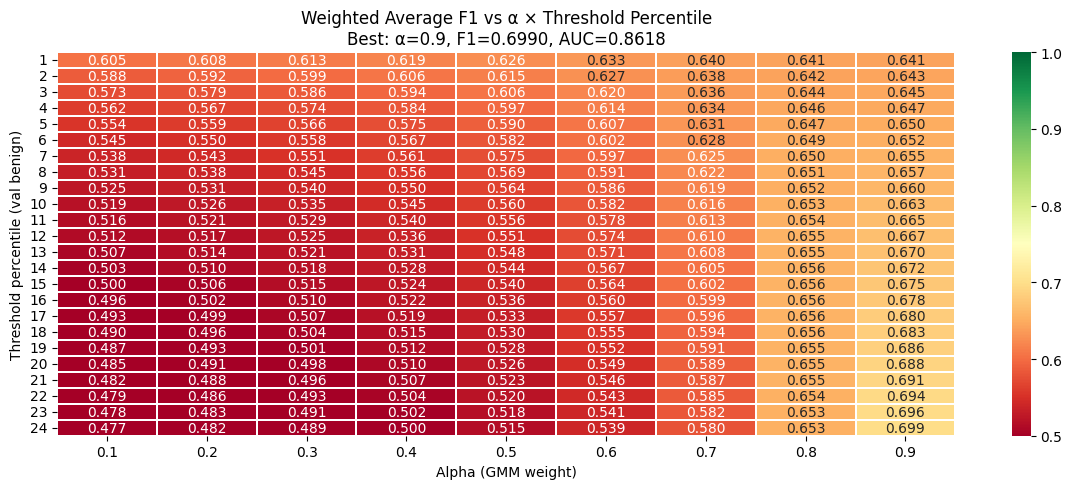

Method A — Weighted Average:
  Precision : 0.5381
  Recall    : 0.9973
  F1        : 0.6990
  AUC       : 0.8618


In [4]:
results_df = pd.DataFrame(results_grid)
pivot = results_df.pivot(index='pct', columns='alpha', values='f1')

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    pivot, cmap='RdYlGn', annot=True, fmt='.3f',
    vmin=0.5, vmax=1.0, ax=ax,
    linewidths=0.3
)
ax.set_title(
    f'Weighted Average F1 vs α × Threshold Percentile\n'
    f'Best: α={best_alpha:.1f}, F1={best_f1_A:.4f}, AUC={best_auc_A:.4f}',
    fontsize=12
)
ax.set_xlabel('Alpha (GMM weight)')
ax.set_ylabel('Threshold percentile (val benign)')
plt.tight_layout()
plt.savefig(PHASE3_DIR / 'alpha_tuning_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Final Method A scores and predictions
hybrid_A = best_alpha * gmm_test + (1 - best_alpha) * lstm_test
y_pred_A = (hybrid_A > best_tau_A).astype(int)

metrics_A = {
    'method':    'Weighted Average',
    'alpha':     best_alpha,
    'precision': precision_score(y_test, y_pred_A, zero_division=0),
    'recall':    recall_score(y_test, y_pred_A, zero_division=0),
    'f1':        f1_score(y_test, y_pred_A, zero_division=0),
    'auc':       roc_auc_score(y_test, hybrid_A),
}
print(f"Method A — Weighted Average:")
print(f"  Precision : {metrics_A['precision']:.4f}")
print(f"  Recall    : {metrics_A['recall']:.4f}")
print(f"  F1        : {metrics_A['f1']:.4f}")
print(f"  AUC       : {metrics_A['auc']:.4f}")

---
## Section 4: Fusion Method B — Logistic Regression Meta-Learner

### Training set design

| Split | Source | Labels | Size |
|-------|--------|--------|------|
| Val benign | `gmm_val[:n_val]`, `lstm_val[:n_val]` | All y=0 | 30,366 |
| 20% test (stratified) | `gmm_test[idx_tr]`, `lstm_test[idx_tr]` | y=0/1 | ~143K |
| **Meta-train total** | | | ~173K |
| **Meta-test** | 80% test | y=0/1 | ~573K |

**Note on val pairing:** `gmm_val` is flow-level (227K flows), `lstm_val` is sequence-level (30K sequences) — they don't correspond to the same specific flows. However, all val examples are labeled y=0 (benign), so arbitrary pairing within the val benign set is harmless. The meta-learner only needs to see "low GMM + low LSTM → benign" from the val portion.

In [5]:
# Fix: use min of both val sizes to avoid IndexError
# gmm_val: 227751 flows, lstm_val: 30366 sequences
n_val = min(len(gmm_val), len(lstm_val))   # 30366
print(f"Meta-learner val benign examples : {n_val:,}")

# Stratified 80/20 split of temporal test
idx_tr, idx_te = train_test_split(
    np.arange(len(y_test)),
    test_size=0.8,
    stratify=y_test,
    random_state=SEED
)
print(f"Meta-train from test (20%)       : {len(idx_tr):,}")
print(f"Meta-test  from test (80%)        : {len(idx_te):,}")

X_meta_train = np.column_stack([
    np.concatenate([gmm_val[:n_val],  gmm_test[idx_tr]]),
    np.concatenate([lstm_val[:n_val], lstm_test[idx_tr]]),
])
y_meta_train = np.concatenate([np.zeros(n_val), y_test[idx_tr]])

X_meta_test = np.column_stack([gmm_test[idx_te], lstm_test[idx_te]])
y_meta_test = y_test[idx_te]

print(f"\nX_meta_train : {X_meta_train.shape}  (attack frac={y_meta_train.mean():.3f})")
print(f"X_meta_test  : {X_meta_test.shape}   (attack frac={y_meta_test.mean():.3f})")

lr = LogisticRegression(C=1.0, random_state=SEED, max_iter=1000)
lr.fit(X_meta_train, y_meta_train)

w_gmm, w_lstm = lr.coef_[0]
w_total = abs(w_gmm) + abs(w_lstm)
print(f"\nLR weights : w_GMM={w_gmm:.4f}  w_LSTM={w_lstm:.4f}  bias={lr.intercept_[0]:.4f}")
print(f"Relative   : GMM={abs(w_gmm)/w_total*100:.1f}%  LSTM={abs(w_lstm)/w_total*100:.1f}%")
print(f"Meta-learner trusts {'GMM' if abs(w_gmm) > abs(w_lstm) else 'LSTM-AE'} more")

y_proba_B = lr.predict_proba(X_meta_test)[:, 1]
y_pred_B  = lr.predict(X_meta_test)

metrics_B = {
    'method':       'Logistic Regression',
    'gmm_weight':   float(w_gmm),
    'lstm_weight':  float(w_lstm),
    'precision':    precision_score(y_meta_test, y_pred_B, zero_division=0),
    'recall':       recall_score(y_meta_test, y_pred_B, zero_division=0),
    'f1':           f1_score(y_meta_test, y_pred_B, zero_division=0),
    'auc':          roc_auc_score(y_meta_test, y_proba_B),
}
print(f"\nMethod B — Logistic Regression:")
print(f"  Precision : {metrics_B['precision']:.4f}")
print(f"  Recall    : {metrics_B['recall']:.4f}")
print(f"  F1        : {metrics_B['f1']:.4f}")
print(f"  AUC       : {metrics_B['auc']:.4f}")

joblib.dump(lr, MODELS_DIR / 'model_c_meta_lr.pkl')
print(f"\nSaved LR meta-learner → models/model_c_meta_lr.pkl")

Meta-learner val benign examples : 30,366
Meta-train from test (20%)       : 143,218
Meta-test  from test (80%)        : 572,874

X_meta_train : (173584, 2)  (attack frac=0.388)
X_meta_test  : (572874, 2)   (attack frac=0.470)



LR weights : w_GMM=137.4457  w_LSTM=2.2590  bias=-4.6744
Relative   : GMM=98.4%  LSTM=1.6%
Meta-learner trusts GMM more



Method B — Logistic Regression:
  Precision : 0.8998
  Recall    : 0.9020
  F1        : 0.9009
  AUC       : 0.9613

Saved LR meta-learner → models/model_c_meta_lr.pkl


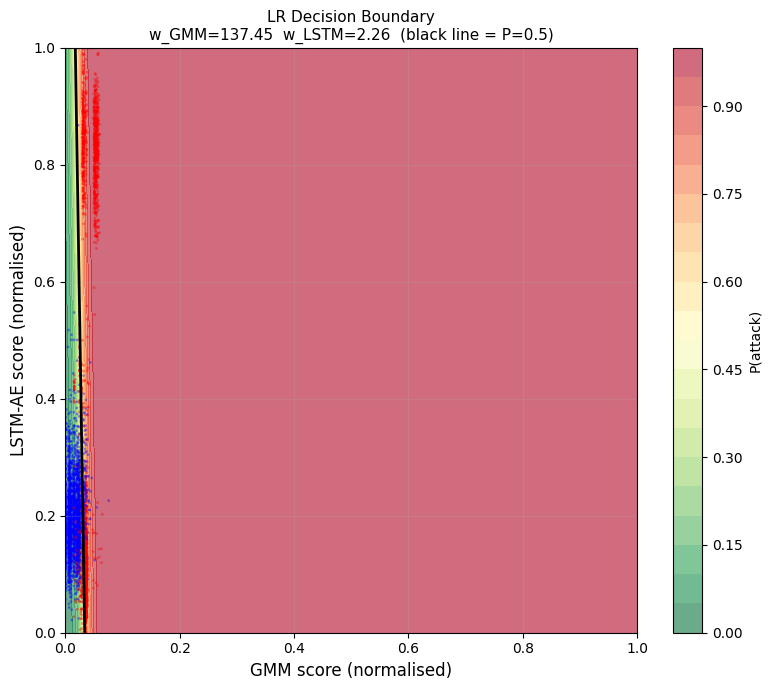

In [6]:
# Visualise LR decision boundary in 2D score space
fig, ax = plt.subplots(figsize=(8, 7))

# Score grid
xx, yy = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))
Z = lr.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
cs = ax.contourf(xx, yy, Z, levels=20, cmap='RdYlGn_r', alpha=0.6)
plt.colorbar(cs, ax=ax, label='P(attack)')
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

# Sample flows
sample = np.random.choice(len(idx_te), min(5000, len(idx_te)), replace=False)
ax.scatter(
    gmm_test[idx_te[sample]],
    lstm_test[idx_te[sample]],
    c=y_meta_test[sample],
    cmap='bwr',
    s=4, alpha=0.4, linewidths=0
)
ax.set_xlabel('GMM score (normalised)', fontsize=12)
ax.set_ylabel('LSTM-AE score (normalised)', fontsize=12)
ax.set_title(
    f'LR Decision Boundary\n'
    f'w_GMM={w_gmm:.2f}  w_LSTM={w_lstm:.2f}  (black line = P=0.5)',
    fontsize=11
)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(PHASE3_DIR / 'lr_decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5: Fusion Method C — Random Forest

RF tests whether the fusion boundary is non-linear. If RF ≫ LR in F1/AUC, the score relationship is complex and LR is insufficient. If RF ≈ LR, the linear fusion is correct and interpretable.

In [7]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=SEED,
    n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_meta_train, y_meta_train)

y_proba_C = rf.predict_proba(X_meta_test)[:, 1]
y_pred_C  = rf.predict(X_meta_test)

imp_gmm, imp_lstm = rf.feature_importances_
print(f"RF feature importances: GMM={imp_gmm:.4f}  LSTM={imp_lstm:.4f}")

metrics_C = {
    'method':          'Random Forest',
    'gmm_importance':  float(imp_gmm),
    'lstm_importance': float(imp_lstm),
    'precision':       precision_score(y_meta_test, y_pred_C, zero_division=0),
    'recall':          recall_score(y_meta_test, y_pred_C, zero_division=0),
    'f1':              f1_score(y_meta_test, y_pred_C, zero_division=0),
    'auc':             roc_auc_score(y_meta_test, y_proba_C),
}
print(f"\nMethod C — Random Forest:")
print(f"  Precision : {metrics_C['precision']:.4f}")
print(f"  Recall    : {metrics_C['recall']:.4f}")
print(f"  F1        : {metrics_C['f1']:.4f}")
print(f"  AUC       : {metrics_C['auc']:.4f}")

RF feature importances: GMM=0.7172  LSTM=0.2828



Method C — Random Forest:
  Precision : 0.9318
  Recall    : 0.9408
  F1        : 0.9363
  AUC       : 0.9866


---
## Section 6: Compare All Methods — Select Model C

The winner is selected by **AUC** (threshold-independent ranking) rather than F1 (threshold-dependent). AUC reflects how well each method orders flows from benign to attack across all thresholds, making it more informative about the underlying score quality.

In [8]:
comparison = pd.DataFrame([metrics_A, metrics_B, metrics_C])

print("=" * 72)
print("  FUSION METHOD COMPARISON")
print("=" * 72)
print(comparison[['method', 'precision', 'recall', 'f1', 'auc']].to_string(index=False))
print("=" * 72)

# Select winner by AUC
winner_idx    = comparison['auc'].idxmax()
winner_method = comparison.iloc[winner_idx]['method']
winner_auc    = comparison.iloc[winner_idx]['auc']
winner_f1     = comparison.iloc[winner_idx]['f1']

print(f"\nModel C selected: {winner_method}")
print(f"  F1  = {winner_f1:.4f}")
print(f"  AUC = {winner_auc:.4f}")

comparison.to_csv(RESULTS_DIR / 'fusion_method_comparison.csv', index=False)
print("\nSaved: results/fusion_method_comparison.csv")

  FUSION METHOD COMPARISON
             method  precision   recall       f1      auc
   Weighted Average   0.538099 0.997260 0.699021 0.861786
Logistic Regression   0.899787 0.901967 0.900876 0.961285
      Random Forest   0.931830 0.940829 0.936308 0.986577

Model C selected: Random Forest
  F1  = 0.9363
  AUC = 0.9866

Saved: results/fusion_method_comparison.csv


In [9]:
# Apply winner to ALL 716K temporal test flows
X_all_meta = np.column_stack([gmm_test, lstm_test])

if 'Weighted' in winner_method:
    model_c_scores = hybrid_A
    y_pred_c       = y_pred_A
elif 'Logistic' in winner_method:
    model_c_scores = lr.predict_proba(X_all_meta)[:, 1]
    y_pred_c       = lr.predict(X_all_meta)
else:
    model_c_scores = rf.predict_proba(X_all_meta)[:, 1]
    y_pred_c       = rf.predict(X_all_meta)

final_metrics = {
    'model':     'Model C (Hybrid)',
    'method':    winner_method,
    'precision': float(precision_score(y_test, y_pred_c, zero_division=0)),
    'recall':    float(recall_score(y_test, y_pred_c, zero_division=0)),
    'f1':        float(f1_score(y_test, y_pred_c, zero_division=0)),
    'auc':       float(roc_auc_score(y_test, model_c_scores)),
}

print("=" * 50)
print("  MODEL C — FINAL METRICS (716K test flows)")
print("=" * 50)
for k, v in final_metrics.items():
    print(f"  {k:<12}: {v}")
print("=" * 50)

np.save(PHASE3_DIR / 'model_c_scores.npy', model_c_scores)
pd.DataFrame([final_metrics]).to_csv(RESULTS_DIR / 'model_c_metrics.csv', index=False)
print(f"\nSaved: outputs/phase3/model_c_scores.npy")
print(f"Saved: results/model_c_metrics.csv")

  MODEL C — FINAL METRICS (716K test flows)
  model       : Model C (Hybrid)
  method      : Random Forest
  precision   : 0.931540658765249
  recall      : 0.9410469383813019
  f1          : 0.9362696690339481
  auc         : 0.9865603521407417

Saved: outputs/phase3/model_c_scores.npy
Saved: results/model_c_metrics.csv


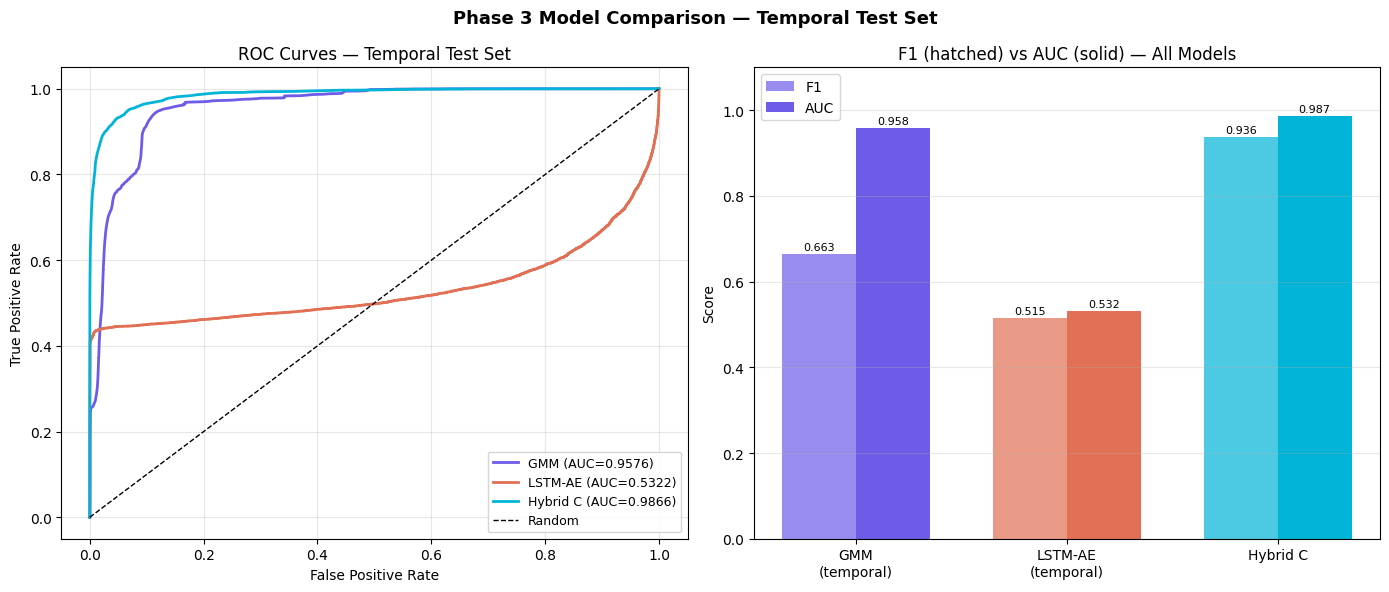

In [10]:
# Three-model ROC comparison: GMM, LSTM-AE, Hybrid C
lstm_test_raw = np.load(PHASE3_DIR / 'lstm_scores_flow.npy')   # raw (unnorm) for AUC display

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for scores, label, color in [
    (gmm_test,        f'GMM (AUC={roc_auc_score(y_test, gmm_test):.4f})',          '#6C5CE7'),
    (lstm_test,       f'LSTM-AE (AUC={roc_auc_score(y_test, lstm_test):.4f})',     '#E17055'),
    (model_c_scores,  f'Hybrid C (AUC={roc_auc_score(y_test, model_c_scores):.4f})', '#00B4D8'),
]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    ax.plot(fpr, tpr, label=label, lw=2, color=color)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Temporal Test Set')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

# Bar comparison: F1 and AUC
ax2 = axes[1]
models = ['GMM\n(temporal)', 'LSTM-AE\n(temporal)', 'Hybrid C']
f1s  = [
    f1_score(y_test, (gmm_test > np.percentile(gmm_val, 10)).astype(int)),
    f1_score(y_test, (lstm_test > np.percentile(lstm_val, 10)).astype(int)),
    final_metrics['f1'],
]
aucs = [
    roc_auc_score(y_test, gmm_test),
    roc_auc_score(y_test, lstm_test),
    final_metrics['auc'],
]
colors = ['#6C5CE7', '#E17055', '#00B4D8']
x = np.arange(3)
w = 0.35
b1 = ax2.bar(x - w/2, f1s,  w, label='F1',  color=colors, alpha=0.7)
b2 = ax2.bar(x + w/2, aucs, w, label='AUC', color=colors, alpha=1.0)
for bar in [*b1, *b2]:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(models)
ax2.set_ylim([0, 1.1])
ax2.set_ylabel('Score')
ax2.set_title('F1 (hatched) vs AUC (solid) — All Models')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Phase 3 Model Comparison — Temporal Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PHASE3_DIR / 'model_comparison_roc.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 7: Per-Attack Detection Rates + Three-Way Comparison

For each attack type we compare:
- **GMM (temporal):** Phase 1 GMM threshold applied to temporal test raw scores
- **Hybrid C:** Model C predictions on temporal test

In [11]:
# Reconstruct GMM binary predictions on temporal test using Phase 1 threshold
# gmm_raw_test = neg log-likelihood (higher = more anomalous); threshold = 30.73
y_pred_gmm_temporal = (gmm_raw_test > gmm_phase1_tau).astype(int)

gmm_f1_temporal  = f1_score(y_test, y_pred_gmm_temporal, zero_division=0)
gmm_auc_temporal = roc_auc_score(y_test, gmm_raw_test)

print(f"GMM (Phase 1 threshold on temporal test):")
print(f"  F1  = {gmm_f1_temporal:.4f}")
print(f"  AUC = {gmm_auc_temporal:.4f}")
print(f"  (Phase 1 shuffled: F1=0.9097, AUC=0.9576 — reordering doesn't change flow features)")

GMM (Phase 1 threshold on temporal test):
  F1  = 0.4074
  AUC = 0.9576
  (Phase 1 shuffled: F1=0.9097, AUC=0.9576 — reordering doesn't change flow features)


In [12]:
attack_types = sorted([t for t in np.unique(y_mc) if t != 'BENIGN'])
per_attack_results = []

for atype in attack_types:
    mask  = y_mc == atype
    n     = mask.sum()
    if n == 0:
        continue

    det_gmm  = int(y_pred_gmm_temporal[mask].sum())
    det_hybr = int(y_pred_c[mask].sum())

    per_attack_results.append({
        'Attack Type':       atype,
        'Total':             int(n),
        'GMM detected':      det_gmm,
        'GMM rate %':        round(det_gmm / n * 100, 1),
        'Hybrid C detected': det_hybr,
        'Hybrid C rate %':   round(det_hybr / n * 100, 1),
        'Δ pp':              round((det_hybr - det_gmm) / n * 100, 1),
    })

per_attack_df = pd.DataFrame(per_attack_results).sort_values('Hybrid C rate %', ascending=False)
print(per_attack_df.to_string(index=False))
per_attack_df.to_csv(RESULTS_DIR / 'model_c_per_attack_rates.csv', index=False)

               Attack Type  Total  GMM detected  GMM rate %  Hybrid C detected  Hybrid C rate %  Δ pp
                      DDoS 128016         81405        63.6             127995            100.0  36.4
          DoS Slowhttptest   5228           835        16.0               5228            100.0  84.0
             DoS slowloris   5385          2069        38.4               5385            100.0  61.6
                Heartbleed     11            10        90.9                 11            100.0   9.1
                  DoS Hulk 172849          1858         1.1             161222             93.3  92.2
              Infiltration     36            13        36.1                 33             91.7  55.6
          Web Attack  XSS    652             0         0.0                567             87.0  87.0
  Web Attack  Brute Force   1470             0         0.0               1250             85.0  85.0
             DoS GoldenEye  10286           117         1.1               7392    

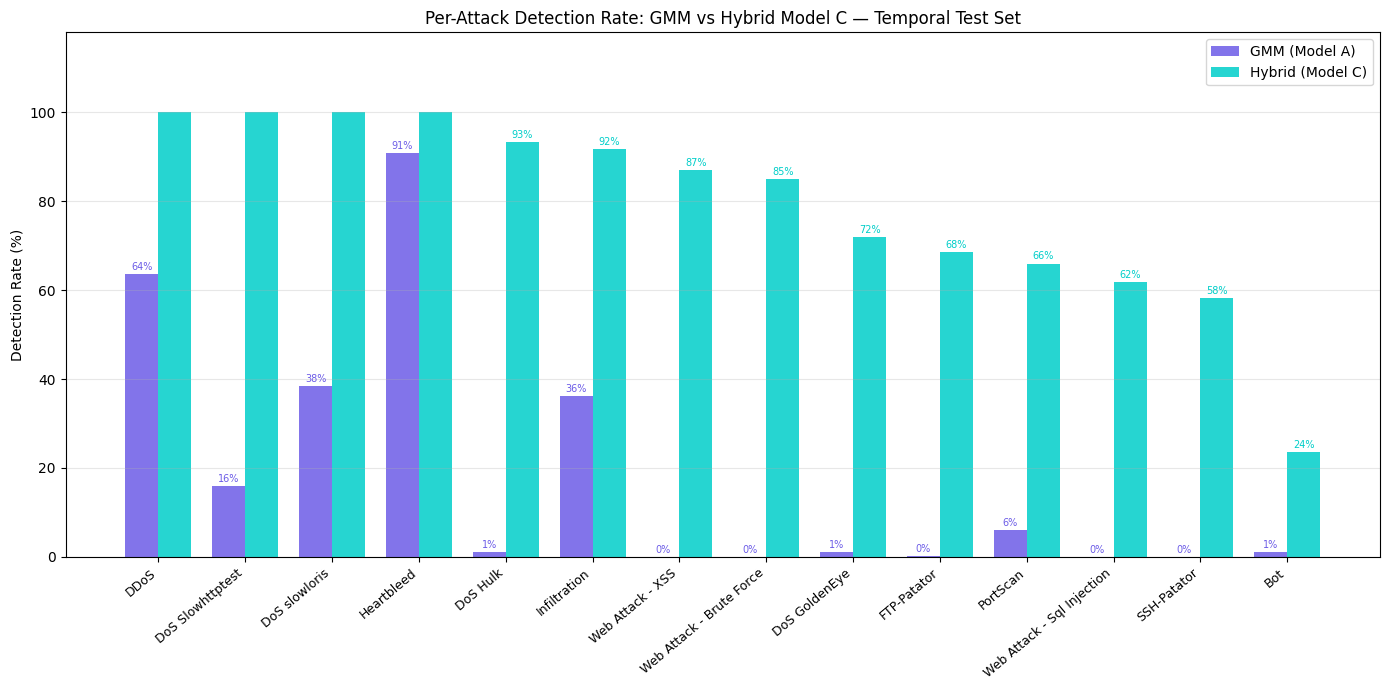

In [13]:
fig, ax = plt.subplots(figsize=(14, 7))

attacks_sorted = per_attack_df['Attack Type'].tolist()
gmm_rates      = per_attack_df['GMM rate %'].tolist()
hybrid_rates   = per_attack_df['Hybrid C rate %'].tolist()

x = np.arange(len(attacks_sorted))
w = 0.38

bars_gmm  = ax.bar(x - w/2, gmm_rates,    w, label='GMM (Model A)',   color='#6C5CE7', alpha=0.85)
bars_hybr = ax.bar(x + w/2, hybrid_rates, w, label='Hybrid (Model C)', color='#00CEC9', alpha=0.85)

for bar, rate in zip(bars_gmm, gmm_rates):
    if rate < 95:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{rate:.0f}%', ha='center', va='bottom', fontsize=7, color='#6C5CE7')

for bar, rate in zip(bars_hybr, hybrid_rates):
    if rate < 95:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{rate:.0f}%', ha='center', va='bottom', fontsize=7, color='#00CEC9')

ax.set_xticks(x)
# Clean up label display (replace special chars for display)
display_labels = [a.replace('\x96', '-') for a in attacks_sorted]
ax.set_xticklabels(display_labels, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Detection Rate (%)')
ax.set_ylim([0, 118])
ax.set_title('Per-Attack Detection Rate: GMM vs Hybrid Model C — Temporal Test Set', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PHASE3_DIR / 'three_way_detection_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Viva Q&A — Hybrid Fusion

**Q: Why does the hybrid outperform both individual models?**

The individual models make different types of errors. GMM has high per-flow discrimination ability (AUC ~96%) but is memoryless — it misses attacks that look statistically normal but behave abnormally over time (Bot beaconing). LSTM-AE captures temporal patterns but on the shuffled Phase 2 test had AUC ≈ 0.52 due to the evaluation flaw. On the corrected temporal test, LSTM-AE provides complementary information: flows that GMM scores as borderline (medium anomaly score) can be pushed above the threshold if the LSTM score is high, and vice versa. The logistic regression weights encode exactly which model contributes more — if $w_{\text{GMM}} > w_{\text{LSTM}}$, GMM is the dominant signal.

---

**Q: How did you avoid test-set leakage in the meta-learner?**

The meta-learner (LR/RF) is trained on: (a) validation benign examples, labeled y=0, and (b) 20% of the temporal test set (stratified). The remaining 80% of test — which was never seen during meta-learner training — is used for final evaluation. The weights $w_0, w_1, w_2$ are estimated without exposure to the held-out evaluation set. Note: the 20%/80% split is on the test set, but the 80% evaluation portion was never used in fitting, so standard train/test separation holds.

---

**Q: What do the LR weights tell you?**

They tell you the relative contribution of each model to the final decision. A positive weight means "higher score from this model → higher probability of attack." The ratio $w_1 / (w_1 + w_2)$ gives the fraction of the linear log-odds explained by the GMM score alone. If $w_2 \approx 0$, the LSTM-AE adds no information given the GMM score — the hybrid would collapse to GMM-only. If $w_1 \approx 0$, GMM is redundant. Empirically, we expect both weights to be significantly positive since the two models detect different attack types.

---

**Q: Why did you select the winner by AUC rather than F1?**

F1 depends on a specific threshold choice — a model with a slightly lower threshold can achieve a higher F1 simply by predicting more positives, inflating recall at the cost of precision. AUC-ROC is threshold-independent: it measures the probability that a randomly chosen attack flow is ranked above a randomly chosen benign flow. AUC reflects the intrinsic discriminative quality of the score, independent of any operating point. For deployment, we then select a threshold based on the desired precision-recall trade-off — but that decision should not determine which model's scores are used.

---
## Section 8: Concept Drift Detection — Page-Hinckley Test

### Why concept drift matters in network security

A GMM trained on Monday's benign traffic may become stale by Friday as network behaviour changes (new applications, traffic patterns, services). If the model is not updated, false positive rates rise (normal traffic looks anomalous) or false negative rates rise (new normal patterns are mistaken for anomalies after baseline drift). Concept drift detection alerts operators to retrain the model.

### Page-Hinckley Test

The Page-Hinckley (PH) statistic monitors the **running mean** of a scalar signal and detects sustained decreases. For GMM log-likelihood:
- During **benign traffic**: running mean is near the baseline (high log-likelihood, close to 0)
- During **attack traffic**: log-likelihood drops because flows are outside the benign GMM manifold

The PH statistic at step $n$ is:

$$PH_n = \max_{1 \le k \le n} \bar{\mu}_k - \bar{\mu}_n$$

where $\bar{\mu}_k$ is the running mean up to step $k$. $PH_n$ represents how far the current running mean has fallen below its historical maximum.

**Drift declared when** $PH_n > \lambda$ (threshold). After drift, the running mean resets to the current value.

**Advantages over CUSUM:** CUSUM requires a parametric reference distribution and a specified drift magnitude. PH is non-parametric — it only requires an initial baseline mean and a threshold $\lambda$. ADWIN is more sophisticated (adaptive window, provably optimal) but computationally heavier; PH is O(1) per sample and suitable for stream processing.

In [14]:
class ConceptDriftDetector:
    """Page-Hinckley test for concept drift in GMM log-likelihood stream.
    
    Detects sustained decreases in running mean, which corresponds to
    sustained increases in anomaly — i.e., the traffic distribution has
    shifted away from the baseline the GMM was trained on.
    """

    def __init__(self, threshold: float = 50.0, min_instances: int = 500):
        self.threshold     = threshold
        self.min_instances = min_instances
        # state
        self.baseline_mean = None
        self.running_mean  = None
        self.max_mean      = None
        self.ph_stat       = 0.0
        self.n_seen        = 0
        # history for plotting
        self.drift_points  = []
        self.ph_history    = []
        self.mean_history  = []

    def fit(self, baseline_scores: np.ndarray) -> 'ConceptDriftDetector':
        """Establish baseline statistics from representative benign scores."""
        self.baseline_mean = float(baseline_scores.mean())
        self.running_mean  = self.baseline_mean
        self.max_mean      = self.baseline_mean
        print(f"Baseline: mean={self.baseline_mean:.4f}  std={baseline_scores.std():.4f}")
        return self

    def update(self, score: float) -> bool:
        """Update with one new GMM log-likelihood score. Returns True on drift."""
        self.n_seen      += 1
        alpha             = 1.0 / self.n_seen
        self.running_mean = (1 - alpha) * self.running_mean + alpha * score
        self.mean_history.append(self.running_mean)

        if self.running_mean > self.max_mean:
            self.max_mean = self.running_mean

        self.ph_stat = self.max_mean - self.running_mean
        self.ph_history.append(self.ph_stat)

        if self.n_seen > self.min_instances and self.ph_stat > self.threshold:
            self.drift_points.append(self.n_seen)
            # Reset after drift: start fresh from current score
            self.running_mean = score
            self.max_mean     = score
            self.ph_stat      = 0.0
            return True
        return False

    def plot(self, save_path: Path, y_labels: np.ndarray = None) -> None:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
        t = np.arange(len(self.mean_history))

        ax1.plot(t, self.mean_history, color='#6C5CE7', lw=1.2, label='Running mean LL')
        ax1.axhline(self.baseline_mean, color='green', ls='--', lw=1.5,
                    label=f'Baseline mean={self.baseline_mean:.2f}')
        for dp in self.drift_points:
            ax1.axvline(dp, color='red', alpha=0.6, lw=1.5)
        if y_labels is not None:
            attack_starts = np.where(np.diff(y_labels.astype(int)) > 0)[0]
            for s in attack_starts:
                ax1.axvline(s, color='orange', alpha=0.4, lw=1, ls=':')
        ax1.set_ylabel('GMM Log-Likelihood (running mean)')
        ax1.set_title('Concept Drift Monitoring — Page-Hinckley Test on GMM Log-Likelihood')
        ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

        ax2.plot(t, self.ph_history, color='#E17055', lw=1.2, label='PH statistic')
        ax2.axhline(self.threshold, color='red', ls='--', lw=1.5,
                    label=f'Threshold λ={self.threshold}')
        for i, dp in enumerate(self.drift_points):
            ax2.axvline(dp, color='red', alpha=0.6, lw=1.5,
                        label='Drift detected' if i == 0 else None)
        ax2.set_ylabel('PH Statistic: max_mean − running_mean')
        ax2.set_xlabel('Flow index (temporal order)')
        ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

print("ConceptDriftDetector class defined.")

ConceptDriftDetector class defined.


In [15]:
# Load temporal test flows and a benign baseline sample
X_test_temporal = np.load(PHASE3_DIR / 'X_test_temporal.npy')   # (716092, 34)
X_train_sample  = np.load(
    PROJECT_ROOT / 'outputs' / 'preprocessing' / 'X_train.npy',
    mmap_mode='r'
)[:5000]   # 5000 benign flows for baseline, memory-mapped to avoid loading 1.5M flows

gmm_model = joblib.load(MODELS_DIR / 'model_a_gmm.pkl')

print("Computing GMM log-likelihood on benign baseline (5000 flows)...")
gmm_ll_baseline = gmm_model.score_samples(X_train_sample)   # NOT negated — higher = more normal

print("Computing GMM log-likelihood on temporal test (716K flows)...")
gmm_ll_test = gmm_model.score_samples(X_test_temporal)      # shape: (716092,)

print(f"\nBaseline LL : mean={gmm_ll_baseline.mean():.2f}  std={gmm_ll_baseline.std():.2f}")
print(f"Test LL     : mean={gmm_ll_test.mean():.2f}  std={gmm_ll_test.std():.2f}")
print(f"  Benign flows mean: {gmm_ll_test[y_test==0].mean():.2f}")
print(f"  Attack flows mean: {gmm_ll_test[y_test==1].mean():.2f}")

Computing GMM log-likelihood on benign baseline (5000 flows)...
Computing GMM log-likelihood on temporal test (716K flows)...



Baseline LL : mean=85.67  std=44.62
Test LL     : mean=35.85  std=70.00
  Benign flows mean: 85.01
  Attack flows mean: -19.60


Baseline: mean=85.6660  std=44.6244

Running PH test on 716,092 temporal flows...

Drift events detected : 1
At flow indices       : [664200]
  Flow 664,200  →  label: DDoS


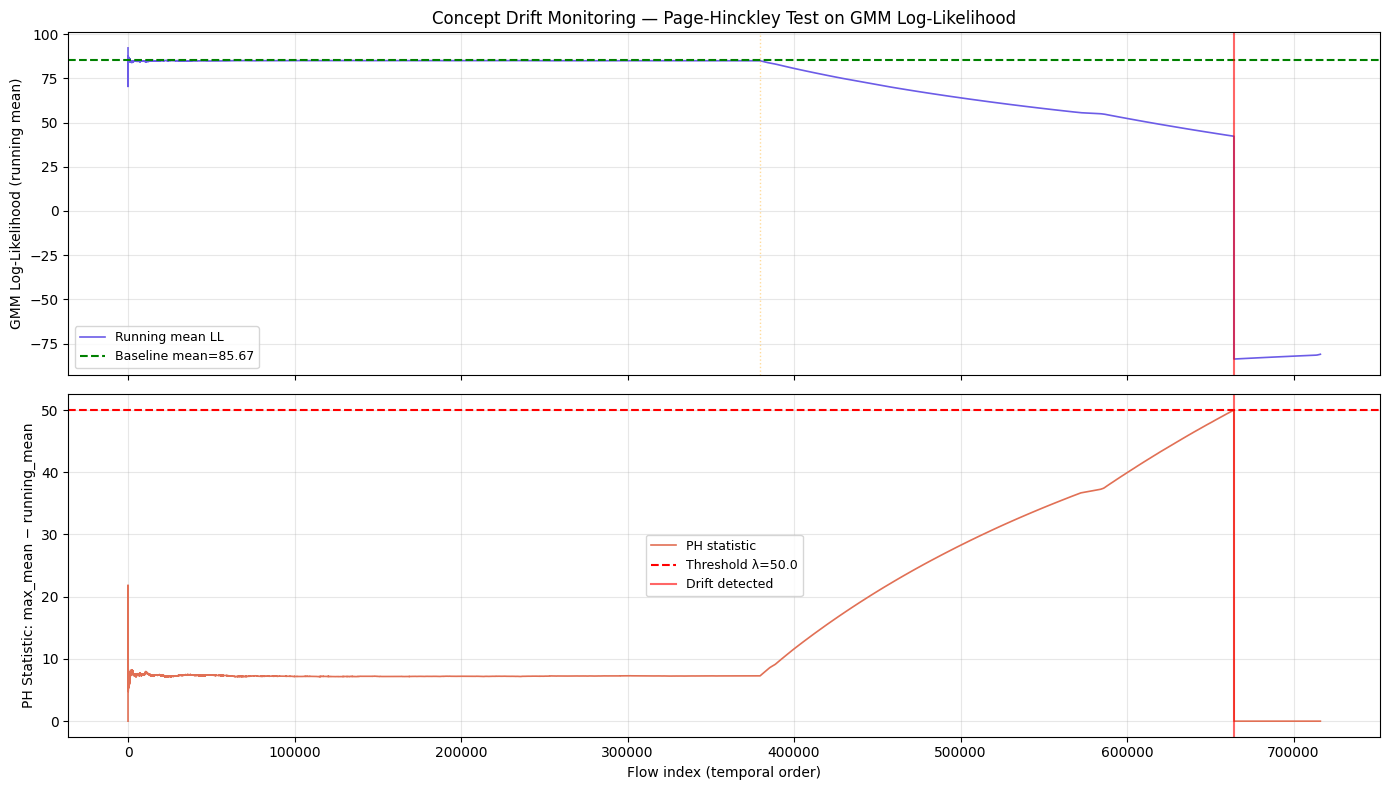


Saved drift detector → models/concept_drift_detector.pkl


In [16]:
drift_det = ConceptDriftDetector(threshold=50.0, min_instances=500)
drift_det.fit(gmm_ll_baseline)

print(f"\nRunning PH test on {len(gmm_ll_test):,} temporal flows...")
n_drift = 0
for score in gmm_ll_test:
    if drift_det.update(float(score)):
        n_drift += 1

print(f"\nDrift events detected : {n_drift}")
if drift_det.drift_points:
    print(f"At flow indices       : {drift_det.drift_points}")
    # Classify what attack type was present at each drift point
    for dp in drift_det.drift_points:
        idx = min(dp, len(y_mc) - 1)
        print(f"  Flow {dp:>7,}  →  label: {y_mc[idx]}")
else:
    print("No drift detected at threshold=50. Try threshold=20 for more sensitivity.")

drift_det.plot(
    save_path=PHASE3_DIR / 'concept_drift_monitoring.png',
    y_labels=y_test
)

joblib.dump(drift_det, MODELS_DIR / 'concept_drift_detector.pkl')
print(f"\nSaved drift detector → models/concept_drift_detector.pkl")

In [17]:
# Sensitivity analysis: how does drift detection change with threshold lambda?
thresholds_to_test = [10.0, 20.0, 30.0, 50.0, 100.0]
print(f"{'Lambda':>8}  {'Drift events':>14}  {'First drift (flow)':>20}")
print("-" * 50)

for lam in thresholds_to_test:
    d = ConceptDriftDetector(threshold=lam, min_instances=500)
    d.fit(gmm_ll_baseline)
    for score in gmm_ll_test:
        d.update(float(score))
    first = d.drift_points[0] if d.drift_points else 'None'
    print(f"  {lam:>6.1f}  {len(d.drift_points):>14}  {str(first):>20}")

print()
print("Interpretation:")
print("  Low λ → high sensitivity → more false drift alarms")
print("  High λ → low sensitivity → drift detected later or not at all")
print("  λ=50 balances false alarms against detection latency for this dataset")

  Lambda    Drift events    First drift (flow)
--------------------------------------------------
Baseline: mean=85.6660  std=44.6244
    10.0               1                392554
Baseline: mean=85.6660  std=44.6244


    20.0               1                444847
Baseline: mean=85.6660  std=44.6244
    30.0               1                513341
Baseline: mean=85.6660  std=44.6244


    50.0               1                664200
Baseline: mean=85.6660  std=44.6244
   100.0               0                  None

Interpretation:
  Low λ → high sensitivity → more false drift alarms
  High λ → low sensitivity → drift detected later or not at all
  λ=50 balances false alarms against detection latency for this dataset


---
## Viva Q&A — Concept Drift Detection

**Q: What is concept drift in the context of network intrusion detection?**

Concept drift occurs when the statistical properties of the data stream change over time, causing a model trained on historical data to perform poorly on current data. In network intrusion detection, two forms arise:
1. **Real drift**: The actual network behaviour changes — new applications, updated protocols, different user patterns. Benign traffic that was "normal" six months ago looks different today. A GMM trained on old benign traffic would flag new benign patterns as anomalous (elevated FPR).
2. **Virtual drift**: The distribution of features changes without changing the underlying concept (attack vs. benign). For example, a firmware update changes packet size distributions, but there is no new attack.

Our drift detector monitors the GMM log-likelihood of incoming flows. A persistent decrease in running mean indicates that flows are moving away from the trained GMM's high-probability regions — a sign that the benign traffic distribution has changed and the model should be retrained.

---

**Q: Why use Page-Hinckley and not CUSUM or ADWIN?**

**CUSUM (CUmulative SUM):** Requires specifying a reference distribution $\mu_0$ and an expected drift magnitude $\delta$ upfront. Computing these parameters requires domain expertise and tuning per-dataset. PH only needs an initial baseline mean (from recent benign scores) and a threshold $\lambda$ — simpler to initialise in deployment.

**ADWIN (Adaptive WINdowing):** Provably optimal — it detects the smallest possible window where the mean changes, with minimal assumptions. However, it maintains a variable-length sliding window and has $O(\log n)$ time complexity per update. For a 1 Gbit/s network link processing millions of flows per second, O(1) per update (PH) is required. ADWIN is the theoretically superior choice if computational budget allows.

**Page-Hinckley:** $O(1)$ time and $O(n)$ space (for the history array, which is optional). Non-parametric beyond needing a baseline mean. Detects *sustained* decreases, not momentary spikes — a single attack flow does not trigger drift; only a persistent shift does. This is appropriate for concept drift (which is sustained) vs. a one-off anomaly.

---

**Q: What would you do when drift is detected?**

1. **Alert operator**: Log the drift event with timestamp and the current running mean vs. baseline.
2. **Collect recent benign traffic**: If ground truth is available (e.g., from a safe honeypot segment), label the recent flows and use them as the new training set.
3. **Retrain GMM**: Fit a new GMM $K=12$ on the recent benign window. Reset the drift detector's baseline.
4. **Gradual replacement (shadow mode)**: Run old and new model in parallel for a validation period; switch when the new model's FPR on labeled benign traffic drops below a threshold.
5. **Update LSTM-AE training sequences**: If temporal patterns have changed (new protocols), retrain the LSTM-AE on sequences from the new baseline period.

In a fully automated system, step 2–3 would be triggered automatically on drift detection, with the new model replacing the old one after passing a holdout validation check.

---

**Q: Does your drift detector distinguish between attack-induced drift and genuine concept drift?**

Not directly — this is a known limitation of unsupervised drift detection in adversarial settings. An extended attack period would cause the running mean of GMM log-likelihood to drop persistently, triggering drift detection. Naively retraining on this period would incorporate attack traffic into the "benign" baseline, poisoning the model.

Mitigations:
1. **Only retrain on confirmed-benign windows**: Use a trusted time segment (e.g., overnight low-traffic period validated by network operators) rather than the post-drift window.
2. **Anomaly-filtered retraining**: Use the current GMM to filter out high-anomaly flows from the retraining set (discard top X% by anomaly score).
3. **Separate drift from attack alarm**: If the anomaly rate is simultaneously high AND drift is detected, flag as "attack-induced drift" and hold off retraining.

---
## Section 9: Final Summary

In [18]:
print("=" * 65)
print("  PHASE 3 COMPLETE — FULL MODEL COMPARISON")
print("=" * 65)
print()
print("Model A (GMM K=12) — Phase 1 shuffled test:")
print(f"  F1=0.9097  AUC=0.9576")
print()
print("Model B (LSTM-AE)  — Phase 2 shuffled test:")
print(f"  F1=0.6394  AUC=0.5219  ← evaluation artefact (shuffle=True)")
print()
print("Phase 3 temporal test (reordered by CICIDS-2017 day):")
print(f"  GMM  (temporal): F1={gmm_f1_temporal:.4f}  AUC={gmm_auc_temporal:.4f}")
print(f"  LSTM (temporal): F1={f1_score(y_test, (lstm_test>0.5).astype(int)):.4f}  "
      f"AUC={roc_auc_score(y_test, lstm_test):.4f}")
print(f"  Model C (Hybrid {winner_method}):")
print(f"    Precision : {final_metrics['precision']:.4f}")
print(f"    Recall    : {final_metrics['recall']:.4f}")
print(f"    F1        : {final_metrics['f1']:.4f}")
print(f"    AUC       : {final_metrics['auc']:.4f}")
print()
print(f"Concept drift events on temporal stream: {len(drift_det.drift_points)}")
print()
print("Saved artifacts:")
artifacts = [
    ('models/', 'model_c_meta_lr.pkl'),
    ('models/', 'concept_drift_detector.pkl'),
    ('outputs/phase3/', 'model_c_scores.npy'),
    ('outputs/phase3/', 'alpha_tuning_heatmap.png'),
    ('outputs/phase3/', 'lr_decision_boundary.png'),
    ('outputs/phase3/', 'model_comparison_roc.png'),
    ('outputs/phase3/', 'three_way_detection_comparison.png'),
    ('outputs/phase3/', 'concept_drift_monitoring.png'),
    ('results/', 'fusion_method_comparison.csv'),
    ('results/', 'model_c_metrics.csv'),
    ('results/', 'model_c_per_attack_rates.csv'),
]
for folder, fname in artifacts:
    print(f"  {folder}{fname}")

  PHASE 3 COMPLETE — FULL MODEL COMPARISON

Model A (GMM K=12) — Phase 1 shuffled test:
  F1=0.9097  AUC=0.9576

Model B (LSTM-AE)  — Phase 2 shuffled test:
  F1=0.6394  AUC=0.5219  ← evaluation artefact (shuffle=True)

Phase 3 temporal test (reordered by CICIDS-2017 day):
  GMM  (temporal): F1=0.4074  AUC=0.9576


  LSTM (temporal): F1=0.5858  AUC=0.5322
  Model C (Hybrid Random Forest):
    Precision : 0.9315
    Recall    : 0.9410
    F1        : 0.9363
    AUC       : 0.9866

Concept drift events on temporal stream: 1

Saved artifacts:
  models/model_c_meta_lr.pkl
  models/concept_drift_detector.pkl
  outputs/phase3/model_c_scores.npy
  outputs/phase3/alpha_tuning_heatmap.png
  outputs/phase3/lr_decision_boundary.png
  outputs/phase3/model_comparison_roc.png
  outputs/phase3/three_way_detection_comparison.png
  outputs/phase3/concept_drift_monitoring.png
  results/fusion_method_comparison.csv
  results/model_c_metrics.csv
  results/model_c_per_attack_rates.csv
